In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
using JPEC, Plots

  Activating project at `c:\Users\thlmi\OneDrive\바탕 화면\서울대\대학원\codes\JPEC_github`


In [2]:

# Make sine and cosine spline
xs = range(0.0, stop=2*pi, length=20)
xs = collect(xs)
fs = sin.(xs)
fc = cos.(xs)
# Make a vector of vectors of (100,2) for the spline
fs_matrix = hcat(fs, fc)

print(xs)


[0.0, 0.3306939635357677, 0.6613879270715354, 0.9920818906073031, 1.3227758541430708, 1.6534698176788385, 1.9841637812146062, 2.3148577447503738, 2.6455517082861415, 2.9762456718219092, 3.306939635357677, 3.6376335988934447, 3.9683275624292125, 4.29902152596498, 4.6297154895007475, 4.960409453036515, 5.291103416572283, 5.621797380108051, 5.9524913436438185, 6.283185307179586]

In [3]:
spline = JPEC.SplinesMod.spline_setup(xs, fs_matrix, 2)

 ******
   nqty =           1
 -0.9664726E+00   0.2370817E+01   0.2774426E+00  -0.7448798E+00  -0.1774445E+01  -0.1958256E+01  -0.1384608E+01  -0.5098319E-01   0.6682711E+00   0.3473127E+01
  0.2105687E+01  -0.1791307E+01  -0.1785289E+01  -0.1870602E+01  -0.9377437E+00   0.3175865E+00   0.1501651E+01   0.1874767E+01   0.2105287E+01
   nqty =           2
 -0.6900482E+00   0.1783887E+01  -0.3502720E+00  -0.1303069E+01  -0.1985125E+01  -0.1748510E+01  -0.8217494E+00   0.5589865E+00   0.1321511E+01   0.2949207E+01
  0.1033989E+01  -0.2123343E+01  -0.1870059E+01  -0.1502426E+01  -0.3191937E+00   0.9449477E+00   0.1843393E+01   0.1886920E+01   0.1411989E+01
 !!!!!!
 **&&&**
 @@@@


JPEC.SplinesMod.CubicSpline.RealSplineType(Ptr{Nothing} @0x000001ef331524c0, [0.0, 0.3306939635357677, 0.6613879270715354, 0.9920818906073031, 1.3227758541430708, 1.6534698176788385, 1.9841637812146062, 2.3148577447503738, 2.6455517082861415, 2.9762456718219092, 3.306939635357677, 3.6376335988934447, 3.9683275624292125, 4.29902152596498, 4.6297154895007475, 4.960409453036515, 5.291103416572283, 5.621797380108051, 5.9524913436438185, 6.283185307179586], [0.0 1.0; 0.32469946920468346 0.9458172417006346; … ; -0.32469946920468373 0.9458172417006346; -2.4492935982947064e-16 1.0], 19, 2, 0, 2)

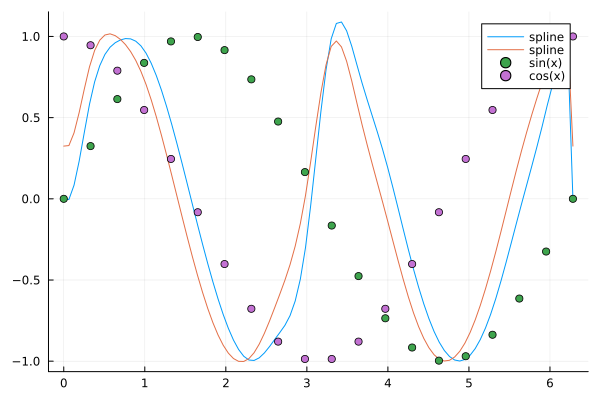

In [8]:
# example: f = GPECsplines.spline_eval(spline, 3.2)
# plot the spline
xs_fine = collect(range(0.0, stop=2*pi, length=100))
fs_fine = JPEC.SplinesMod.spline_eval(spline, xs_fine)
plot(xs_fine, fs_fine, label="spline", legend=:topright)
# plot the input data scatter
scatter!(xs, fs, label="sin(x)", legend=:topright)
scatter!(xs, fc, label="cos(x)", legend=:topright)

In [8]:
# Make e^-ix and e^ix spline
xs = range(0.0, stop=2*pi, length=20)
xs = collect(xs)
fm = exp.(-im .* xs)
fp = exp.(im .* xs)
# Make a vector of vectors of (100,2) for the spline
fs_matrix = hcat(fm, fp)

spline = JPEC.SplinesMod.spline_setup(xs, fs_matrix, 2)


hi2

JPEC.SplinesMod.CubicSpline.ComplexSplineType(Ptr{Nothing} @0x000000012b7890c0, [0.0, 0.3306939635357677, 0.6613879270715354, 0.9920818906073031, 1.3227758541430708, 1.6534698176788385, 1.9841637812146062, 2.3148577447503738, 2.6455517082861415, 2.9762456718219092, 3.306939635357677, 3.6376335988934447, 3.9683275624292125, 4.29902152596498, 4.6297154895007475, 4.960409453036515, 5.291103416572283, 5.621797380108051, 5.9524913436438185, 6.283185307179586], ComplexF64[1.0 - 0.0im 1.0 + 0.0im; 0.9458172417006346 - 0.32469946920468346im 0.9458172417006346 + 0.32469946920468346im; … ; 0.9458172417006346 + 0.32469946920468373im 0.9458172417006346 - 0.32469946920468373im; 1.0 + 2.4492935982947064e-16im 1.0 - 2.4492935982947064e-16im], 19, 2, 0, 2)

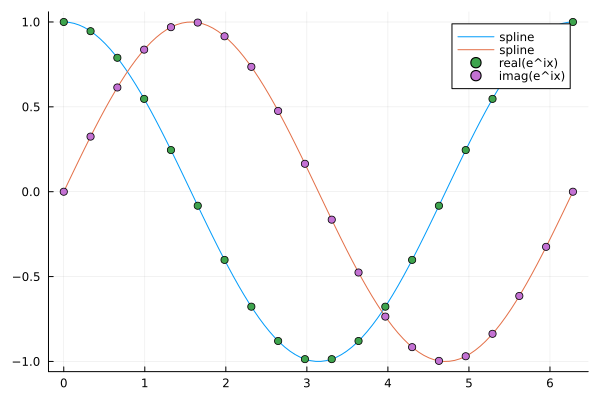

In [9]:
# example: f = GPECsplines.spline_eval(spline, 3.2)
# plot the spline
xs_fine = collect(range(0.0, stop=2*pi, length=100))
fs_fine = JPEC.SplinesMod.spline_eval(spline, xs_fine)

# plot just the real part of e^(+ix)
plot(xs_fine, real(fs_fine[:, 2]), label="spline", legend=:topright)
# and the imaginary part
plot!(xs_fine, imag(fs_fine[:, 2]), label="spline", legend=:topright)
# plot the input data scatter
scatter!(xs, real(fs_matrix[:, 2]), label="real(e^ix)", legend=:topright)
scatter!(xs, imag(fs_matrix[:, 2]), label="imag(e^ix)", legend=:topright)

In [10]:
# make a bicubic spline of a 2d periodic function
xs = range(0.0, stop=2*pi, length=20)
ys = range(0.0, stop=2*pi, length=20)
xs = collect(xs)
ys = collect(ys)
fs1 = sin.(xs') .* cos.(ys) .+ 1.0
fs2 = cos.(xs') .* sin.(ys) .+ 1.0
fs = zeros(20, 20, 2)
# fs is a 20x20x2 array
fs[:, :, 1] = fs1
fs[:, :, 2] = fs2
println("fs size: ", size(fs))

# Make a bicubic spline
bcspline = JPEC.SplinesMod.bicube_setup(xs, ys, fs, 2, 2)

fs size: (20, 20, 2)


JPEC.SplinesMod.BicubicSpline.BicubicSplineType(Ptr{Nothing} @0x000000012caa0800, [0.0, 0.3306939635357677, 0.6613879270715354, 0.9920818906073031, 1.3227758541430708, 1.6534698176788385, 1.9841637812146062, 2.3148577447503738, 2.6455517082861415, 2.9762456718219092, 3.306939635357677, 3.6376335988934447, 3.9683275624292125, 4.29902152596498, 4.6297154895007475, 4.960409453036515, 5.291103416572283, 5.621797380108051, 5.9524913436438185, 6.283185307179586], [0.0, 0.3306939635357677, 0.6613879270715354, 0.9920818906073031, 1.3227758541430708, 1.6534698176788385, 1.9841637812146062, 2.3148577447503738, 2.6455517082861415, 2.9762456718219092, 3.306939635357677, 3.6376335988934447, 3.9683275624292125, 4.29902152596498, 4.6297154895007475, 4.960409453036515, 5.291103416572283, 5.621797380108051, 5.9524913436438185, 6.283185307179586], [1.0 1.3246994692046834 … 0.6753005307953163 0.9999999999999998; 1.0 1.3071063563448337 … 0.6928936436551658 0.9999999999999998; … ; 1.0 1.3071063563448337 … 

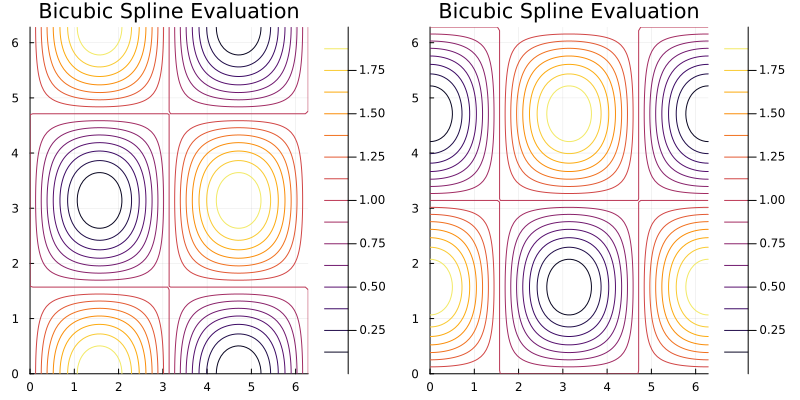

In [11]:
# Evaluate the bicubic spline
xs_fine = collect(range(0.0, stop=2*pi, length=100))
ys_fine = collect(range(0.0, stop=2*pi, length=100))
fs_fine = JPEC.SplinesMod.bicube_eval(bcspline, xs_fine, ys_fine)

# plot the bicubic spline
p1 = contour(xs_fine, ys_fine, fs_fine[:, :, 1], label="sin(x)cos(y)+1", legend=:topright)
p2 = contour(xs_fine, ys_fine, fs_fine[:, :, 2], label="cos(x)sin(y)+1", legend=:topright)
plot(p1, p2, layout=(1, 2), size=(800, 400), title="Bicubic Spline Evaluation")